# Ridge (L2) & Lasso (L1) Regression - Practical Demo
Real-world dataset: Diabetes (sklearn)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


## Step 1: Load Real Dataset

In [2]:
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


## Step 2: Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 3: Feature Scaling (Important for L1/L2)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 4: Baseline - Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

MSE: 2900.1936284934823
R2: 0.45260276297191926


## Step 5: Ridge Regression (L2)

In [6]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2:", r2_score(y_test, y_pred_ridge))

MSE: 2892.0145657501726
R2: 0.45414652070698225


## Step 6: Lasso Regression (L1)

In [7]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2:", r2_score(y_test, y_pred_lasso))

MSE: 2884.6242887352123
R2: 0.45554139902790414


## Step 7: Coefficient Comparison

In [8]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_
})

coef_df

,Feature,Linear,Ridge,Lasso
0,age,1.753758,1.807342,1.730451
1,sex,-11.511809,-11.448190,-11.316359
2,bmi,25.607121,25.732699,25.824627
3,bp,16.828872,16.734300,16.644252
4,s1,-44.448856,-34.671954,-29.358412
5,s2,24.640954,17.053075,13.275844
6,s3,7.676978,3.369914,0.547948
7,s4,13.138784,11.764260,10.236168
8,s5,35.161195,31.378384,29.632826
9,s6,2.351364,2.458139,2.393475


## Step 8: Visualization of Coefficients

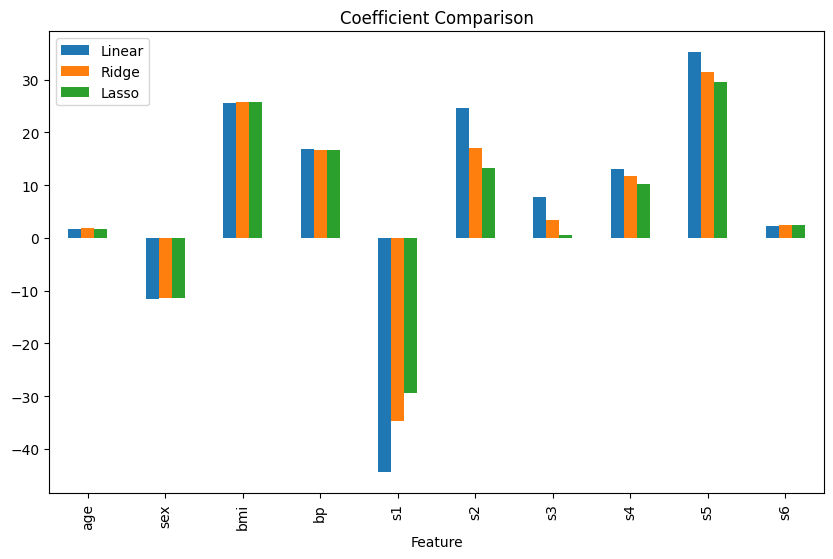

In [9]:
coef_df.set_index('Feature').plot(kind='bar', figsize=(10,6))
plt.title("Coefficient Comparison")
plt.show()

## Step 9: Effect of Alpha

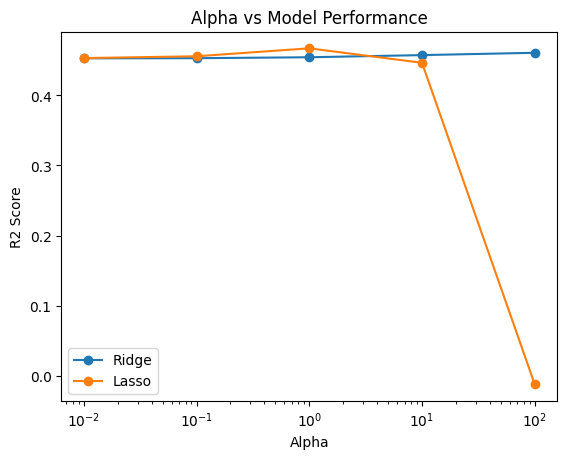

In [10]:
alphas = [0.01, 0.1, 1, 10, 100]
ridge_scores = []
lasso_scores = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_scores.append(ridge.score(X_test_scaled, y_test))

    lasso = Lasso(alpha=a)
    lasso.fit(X_train_scaled, y_train)
    lasso_scores.append(lasso.score(X_test_scaled, y_test))

plt.plot(alphas, ridge_scores, marker='o', label='Ridge')
plt.plot(alphas, lasso_scores, marker='o', label='Lasso')
plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("R2 Score")
plt.title("Alpha vs Model Performance")
plt.legend()
plt.show()